# Tutorial 8 – Equity Screening & Stock Selection Case
## FINM3422 – Professional Equity Research Workflow

**Estimated time:** ~2 hours (group-based)

---

### Scenario

You are part of a junior **equity research team** at an asset management firm.

Management has asked your team to:

> **Screen a universe of NASDAQ-listed technology companies and recommend ONE stock**
> for deeper fundamental analysis later in the course.

This notebook is intentionally structured like a **professional research notebook**,
following the modelling discipline discussed in **Lecture 6**.

You will work **collaboratively** using GitHub feature branches and pull requests.

## 1. Environment & Imports (≈5 minutes)

Professional modelling always begins by making the computing environment explicit.

Why this matters:
- Reproducibility across machines
- Clear collaboration in teams
- Fewer hidden bugs caused by implicit state

In this tutorial, we use **yfinance**, a free and stable Python library that provides
programmatic access to Yahoo Finance data.

No API key is required, which removes setup friction during tutorials.

In [4]:
# If needed (run once): pip install yfinance in console or use %pip install yfinance in your notebook

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

## What is the yfinance API?

`yfinance` is a Python wrapper around Yahoo Finance endpoints.
It allows analysts to retrieve:

- historical price data (daily, weekly, monthly)
- company metadata
- financial statements (income statement, balance sheet, cash flow)

It is:
- ✅ free
- ✅ fast to learn
- ✅ widely used for research prototyping and teaching

⚠️ Important:
`yfinance` is **not an institutional-grade data source** (e.g. Bloomberg or Refinitiv),
but it is perfectly suitable for **learning professional modelling workflows**.

## 2. Define the Investment Universe (≈5 minutes)

Equity research always begins with a clearly defined **investment universe**.

We restrict attention to a curated list of **large‑cap NASDAQ technology companies**.

Using a fixed universe ensures:
- Comparability across tutorial teams
- Stable API behaviour in class
- Focus on modelling rather than data hunting

In [5]:
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "ADBE",  # Adobe
    "META",  # Meta Platforms
    "CRM",   # Salesforce
    "ORCL",  # Oracle
    "NOW",   # ServiceNow
    "INTU",  # Intuit
    "AMD"    # Advanced Micro Devices
]

## 3. Price Data Ingestion – API → DataFrame (≈15 minutes)

In professional workflows, analysts **do not manually download CSV files**.
Instead, data is pulled programmatically via APIs.

The main function used by yfinance is:

    yf.download()

### Key parameters you must understand

- `tickers`
  A single ticker (string) or multiple tickers (list)

- `interval`
  Controls **frequency** of observations  
  Examples:
  - `"1d"`  → daily data
  - `"1wk"` → weekly data
  - `"1mo"` → monthly data

- `period`
  Controls **how much history** is returned  
  Examples:
  - `"1y"`   → last year
  - `"5y"`   → last 5 years
  - `"max"`  → full available history

⚠️ **Critical rule**
> Never rely on API defaults. Always specify `period` explicitly.

## Why We Use Monthly Data in This Tutorial

In FINM3422:
- portfolio returns are monthly
- performance metrics are monthly
- Assignment 2 uses monthly frequency

Therefore, we deliberately request:
- `interval = "1mo"` → monthly observations
- `period = "max"`   → long historical window

This ensures:
- frequency is correct before computing returns
- enough observations exist for rolling metrics
- alignment with Lecture 6 modelling discipline

In [35]:
# TODO:
# Use yf.download to retrieve monthly adjusted prices
# - interval="1mo"
# - period="max"
# - auto_adjust=True
# Then:
# - keep adjusted close prices
# - ensure DatetimeIndex
# - sort index

# Download monthly adjusted price data
prices = yf.download(
    tickers=tickers,
    interval="1mo",     # monthly observations
    period="max",       # long historical window
    auto_adjust=True    # use adjusted prices
)

# Keep adjusted close prices only
prices = prices["Close"]

# Ensure DatetimeIndex
prices.index = pd.to_datetime(prices.index)

# Sort index (important for returns & rolling metrics)
prices = prices.sort_index()

prices.tail(12)


[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-05-01,199.978424,415.089996,110.730003,263.404297,747.388672,645.476257,456.862396,202.218002,135.098175,163.885773
2025-06-01,204.547546,386.880005,141.899994,270.670074,781.273010,735.794495,494.537201,205.615997,157.952789,216.458298
2025-07-01,206.940277,357.690002,176.309998,256.823029,778.793091,771.627808,530.418762,188.623993,177.840439,251.249237
2025-08-01,231.435715,356.700012,162.630005,254.755173,662.511902,736.969238,503.763580,183.492004,174.151047,224.359528
2025-09-01,254.145599,352.750000,161.789993,235.617462,678.314819,732.659302,515.805115,184.056000,186.548996,279.038025
2025-10-01,269.855652,340.309998,256.119995,259.341736,663.058167,647.267456,515.665649,183.856003,202.467773,260.553894
2025-11-01,278.319519,320.130005,217.529999,229.594269,630.964417,646.868164,489.972534,162.481995,176.980560,200.716537
2025-12-01,271.605835,349.989990,214.160004,263.823273,659.165161,658.987854,482.518677,153.190002,186.479538,193.719543
2026-01-01,259.237427,293.250000,236.729996,211.760376,496.468567,715.887085,429.310120,117.010002,191.119659,163.574799


## 4. Data Inspection & Sanity Checks (≈10 minutes)

Before computing metrics, analysts **inspect the raw data**.

You should check:
- `.info()`
- missing values (`.isna().sum()`)
- index type (`type(df.index)`)
- chronological ordering

### Important modelling principle (Lecture 6)

> NA does **not** mean bad data.
> It often means the company did not exist yet (IPO timing).

Different firms have different listing dates.
This is **economically correct**, not an error.

In [13]:
# TODO:
# Inspect the price DataFrame:
# - info()
# - missing values
# - index properties

# Basic structure and data types
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 496 entries, 1985-01-01 to 2026-04-01
Freq: MS
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    496 non-null    float64
 1   ADBE    477 non-null    float64
 2   AMD     496 non-null    float64
 3   CRM     263 non-null    float64
 4   INTU    398 non-null    float64
 5   META    168 non-null    float64
 6   MSFT    482 non-null    float64
 7   NOW     167 non-null    float64
 8   NVDA    328 non-null    float64
 9   ORCL    482 non-null    float64
dtypes: float64(10)
memory usage: 42.6 KB


In [14]:
# Missing values (expected due to different IPO dates)
prices.isna().sum()

Ticker
AAPL      0
ADBE     19
AMD       0
CRM     233
INTU     98
META    328
MSFT     14
NOW     329
NVDA    168
ORCL     14
dtype: int64

In [15]:
# Index properties
type(prices.index)

pandas.core.indexes.datetimes.DatetimeIndex

## 5. Returns & Performance Metrics (≈15 minutes)

Equity screeners often include **recent market performance**
(e.g. momentum or confirmation).

Tasks:
- Compute monthly returns
- Compute trailing 12‑month total return

⚠️ Always fix frequency *before* computing returns.

In [16]:
# TODO:
# 1. Compute monthly returns using pct_change()
# 2. Compute trailing 12‑month total return

In [30]:
# 1. Compute monthly returns
returns = prices.pct_change().dropna()
returns.tail(12)

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-05-01,-0.054823,0.106966,0.137442,-0.010878,0.202904,0.179399,0.164702,0.058722,0.240635,0.180533
2025-06-01,0.022848,-0.067961,0.281495,0.027584,0.045337,0.139925,0.082464,0.016804,0.169170,0.320788
2025-07-01,0.011698,-0.075450,0.242495,-0.051158,-0.003174,0.048700,0.072556,-0.082640,0.125909,0.160728
2025-08-01,0.118370,-0.002768,-0.077591,-0.008052,-0.149310,-0.044916,-0.050253,-0.027208,-0.020746,-0.107024
2025-09-01,0.098126,-0.011074,-0.005165,-0.075122,0.023853,-0.005848,0.023903,0.003074,0.071191,0.243709
2025-10-01,0.061815,-0.035266,0.583040,0.100690,-0.022492,-0.116551,-0.000270,-0.001087,0.085333,-0.066242
2025-11-01,0.031364,-0.059299,-0.150672,-0.114704,-0.048403,-0.000617,-0.049825,-0.116254,-0.125883,-0.229654
2025-12-01,-0.024122,0.093275,-0.015492,0.149085,0.044695,0.018736,-0.015213,-0.057188,0.053672,-0.034860
2026-01-01,-0.045538,-0.162119,0.105388,-0.197340,-0.246822,0.086343,-0.110273,-0.236177,0.024883,-0.155610


In [28]:
# 2. Trailing 12-month total return (momentum-style metric)
trailing_12m = (1 + returns).rolling(window=12).apply(
    lambda x: x.prod() - 1,
    raw=False
)

trailing_12m.tail(12)

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-05-01,0.049666,-0.066710,-0.336549,0.138555,0.315589,0.392053,0.117420,0.539114,0.232972,0.428267
2025-06-01,-0.021320,-0.303596,-0.125208,0.066844,0.206220,0.469166,0.121431,0.306876,0.279277,0.565664
2025-07-01,-0.060966,-0.351600,0.220307,0.005617,0.220706,0.634455,0.285025,0.158069,0.520477,0.840116
2025-08-01,0.018453,-0.379015,0.094709,0.019205,0.065125,0.421859,0.223989,0.073053,0.459621,0.617214
2025-09-01,0.097919,-0.318726,-0.013957,-0.129028,0.106793,0.287287,0.212732,0.028947,0.536882,0.667739
2025-10-01,0.202374,-0.288174,0.777747,-0.100847,0.100867,0.145898,0.283862,-0.014695,0.525671,0.581017
2025-11-01,0.180415,-0.379509,0.585727,-0.297144,-0.005392,0.131751,0.170604,-0.225863,0.280656,0.103434
2025-12-01,0.090526,-0.212940,0.772994,-0.202843,0.060934,0.130921,0.155842,-0.277487,0.389184,0.181281
2026-01-01,0.104464,-0.329638,1.041656,-0.374668,-0.165074,0.042920,0.044341,-0.425509,0.592257,-0.022598


## 6. Visual Diagnostics – Wealth Index (≈15 minutes)

Before trusting any metric, professional analysts **plot a wealth index**.

A wealth index answers:
> What happens to $1 invested over time?

This diagnostic reveals:
- missing months
- compounding errors
- extreme outliers dominating results

<Axes: title={'center': 'Wealth Index: $1 Invested (Monthly)'}, xlabel='Date'>

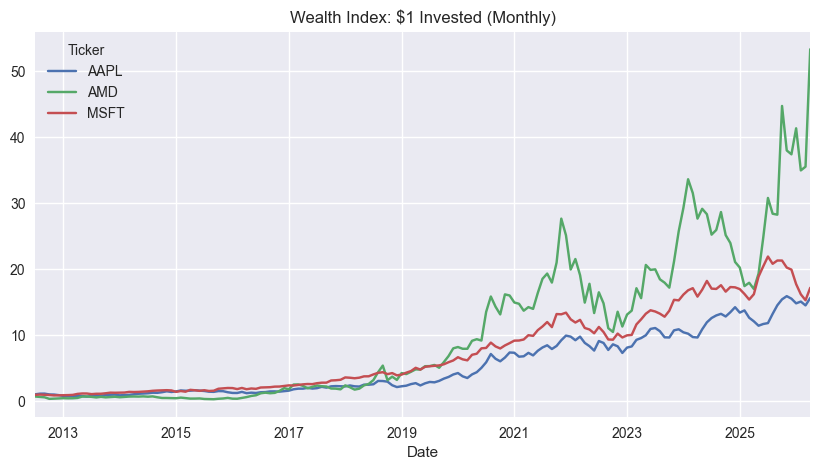

In [38]:
# TODO:
# Construct and plot wealth indices
# Plot at least 3 stocks
# Add a brief interpretation

stocks = ["AAPL", "AMD", "MSFT"]

# Compute wealth index for selected stocks
wealth_index = (1 + returns[stocks]).cumprod()

# Plot wealth indices
wealth_index.plot(
    title="Wealth Index: $1 Invested (Monthly)",
    figsize=(10, 5)
)

## 7. Fundamental Indicators – Growth & Quality (≈20 minutes)

Market prices alone are not sufficient for equity analysis.

We complement price performance with **fundamentals**.

Two indicators:
- **Revenue growth** (latest year vs previous year)
- **Operating margin** (operating income / revenue)

Financial statements are accessed using:

    yf.Ticker("AAPL").financials

In [39]:
# TODO:
# For each ticker:
# - retrieve financial statements using yf.Ticker
# - compute revenue growth
# - compute operating margin
# Store results in a DataFrame

# New DataFrame to store results
results = []

# Loop through tickers and compute financial metrics
for ticker in tickers:
    financials = yf.Ticker(ticker).financials  # annual income statement

    revenue = financials.loc["Total Revenue"]
    op_income = financials.loc["Operating Income"]

    # Revenue growth: latest year vs previous year
    rev_growth = (revenue.iloc[0] / revenue.iloc[1]) - 1

    # Operating margin: operating income / revenue (latest year)
    op_margin = op_income.iloc[0] / revenue.iloc[0]

    results.append({
        "Ticker": ticker,
        "Revenue_Growth": rev_growth,
        "Operating_Margin": op_margin
    })

fundamentals = pd.DataFrame(results).set_index("Ticker")
fundamentals


,Revenue_Growth,Operating_Margin
Ticker,,
AAPL,0.064255,0.319708
MSFT,0.149322,0.456220
NVDA,0.654735,0.603817
ADBE,0.105278,0.366275
META,0.221670,0.414379
CRM,0.095791,0.214738
ORCL,0.083798,0.314500
NOW,0.208849,0.137370
INTU,0.156340,0.262227


## 8. Screening Table Construction (≈15 minutes)

Professional screeners combine **all signals into one master table**.

Structure:
- each row → one stock
- each column → one screening signal

This table forms the basis for ranking and decision‑making.

In [45]:
# TODO:
# Combine:
# - 12‑month return
# - revenue growth
# - operating margin
# into a single screening table

# Last trailing_12m for each stock
last_trailing_12m = trailing_12m.iloc[-1].rename("Trailing_12M_Return")

# Combine into a single screening table
screen = pd.concat(
    [last_trailing_12m, fundamentals],
    axis=1)

screen

,Trailing_12M_Return,Revenue_Growth,Operating_Margin
Ticker,,,
AAPL,0.292338,0.064255,0.319708
ADBE,-0.362686,0.105278,0.366275
AMD,2.136415,0.343378,0.106643
CRM,-0.349233,0.095791,0.214738
INTU,-0.383088,0.156340,0.262227
META,0.204383,0.221670,0.414379
MSFT,0.059892,0.149322,0.456220
NOW,-0.556130,0.208849,0.137370
NVDA,0.833337,0.654735,0.603817


## 9. Ranking & Shortlisting Logic (≈15 minutes)

Equity screening is about **narrowing the universe**, not precision.

Rank stocks using:
- revenue growth
- operating margin
- 12‑month performance

Combine ranks into a **composite score**.

There is no single correct answer —
only defensible logic that can be explained.

In [48]:
# TODO:
# Rank each metric
# Compute composite score
# Sort stocks from most to least attractive

# Ranks stocks by each metric
ranks = screen.rank(ascending=True)

# Compute composite score as average rank
ranks["Composite_Score"] = ranks.mean(axis=1)

# Sort by composite score
shortlist = ranks.sort_values("Composite_Score", ascending=True)
shortlist

,Trailing_12M_Return,Revenue_Growth,Operating_Margin,Composite_Score
Ticker,,,,
CRM,4.0,3.0,3.0,3.333333
NOW,1.0,7.0,2.0,3.333333
INTU,2.0,6.0,4.0,4.000000
ADBE,3.0,4.0,7.0,4.666667
ORCL,7.0,2.0,5.0,4.666667
AAPL,8.0,1.0,6.0,5.000000
MSFT,5.0,5.0,9.0,6.333333
AMD,10.0,9.0,1.0,6.666667
META,6.0,8.0,8.0,7.333333


## 10. Stock Selection – Analyst Decision (≈10 minutes)

Your team must now make a **judgement call**.

Select **ONE stock** to recommend for deeper analysis.

Write as if presenting to an **investment committee**.

In [ ]:
### Selected Stock

### Analyst Rationale
- Growth outlook:
- Profitability / quality:
- Market performance:
- Key risks:

## 11. GitHub Collaboration Reflection (≈10 minutes)

Equity research is a **team activity**.

Document:
- Who worked on which sections
- How feature branches and pull requests were used
- Any challenges encountered

- Member A:
- Member B:
- Member C: